# Adaptive Visual Retrieval — v2
## Region-Level Feedback-Adaptive Multimodal Retrieval

This notebook implements and evaluates the research question in
`research_proposal.md`:

> Does decomposing an image into detected object regions, and applying
> relevance feedback at the region level, converge to the user's intended
> result in fewer rounds than whole-image feedback — specifically on
> cluttered, multi-object images?

Structure mirrors the ablation table directly: four conditions, run and
evaluated side by side, rather than building only the final proposed system.


## 0. Setup

In [1]:
# !pip install open_clip_torch ultralytics matplotlib scikit-learn --quiet

import torch
import open_clip
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import json
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cpu


## 1. Load models

Reuses the v1 CLIP backbone (OpenCLIP ViT-B/32) for a fair baseline
comparison, plus a detector for the region-level conditions.


In [2]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(device).eval()
tokenizer = open_clip.get_tokenizer("ViT-B-32")

# TODO: swap for a stronger open-vocab detector (e.g. OWL-ViT) if YOLOv8's
# fixed classes are too restrictive for the query set's object categories.
detector = YOLO("yolov8n.pt")


## 2. Query sets

Two labeled query sets are required (see `dataset.md` for the spec):
- `queries_simple.json` — single-subject images
- `queries_cluttered.json` — multi-object images

Each entry: `{"query": str | image_path, "query_type": "text"|"image",
"relevant_image_ids": [...]}`.

**TODO:** curate ~50 queries per set before running the ablation below.


In [3]:
def load_query_set(path):
    with open(path) as f:
        return json.load(f)

# queries_simple = load_query_set("data/queries_simple.json")
# queries_cluttered = load_query_set("data/queries_cluttered.json")


## 3. Detection → region extraction

In [4]:
def extract_regions(image_path, conf_threshold=0.25):
    """Run detector, return list of (crop: PIL.Image, bbox, conf) per image.
    Falls back to the full image as a single 'region' if nothing is detected,
    so downstream code doesn't need special-casing.
    """
    results = detector(image_path, conf=conf_threshold, verbose=False)[0]
    img = Image.open(image_path).convert("RGB")
    regions = []
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])
        regions.append((img.crop((x1, y1, x2, y2)), (x1, y1, x2, y2), conf))
    if not regions:
        regions = [(img, (0, 0, img.width, img.height), 1.0)]
    return regions


## 4. Multimodal embedding (whole-image and region-level)

In [5]:
@torch.no_grad()
def embed_image(pil_image):
    tensor = clip_preprocess(pil_image).unsqueeze(0).to(device)
    feat = clip_model.encode_image(tensor)
    return (feat / feat.norm(dim=-1, keepdim=True)).cpu().numpy()[0]

@torch.no_grad()
def embed_text(text):
    tokens = tokenizer([text]).to(device)
    feat = clip_model.encode_text(tokens)
    return (feat / feat.norm(dim=-1, keepdim=True)).cpu().numpy()[0]

def embed_regions(image_path):
    """Returns list of (embedding, bbox, conf) for every detected region."""
    regions = extract_regions(image_path)
    return [(embed_image(crop), bbox, conf) for crop, bbox, conf in regions]


## 5. Feedback-adaptive re-ranking (Rocchio-style)

Same update rule for both whole-image and region-level conditions — the
difference is *what* the feedback is attached to (one embedding per image vs.
one embedding per region).


In [6]:
def rocchio_update(query_vec, relevant_vecs, irrelevant_vecs, alpha=1.0, beta=0.75, gamma=0.15):
    query_vec = np.array(query_vec)
    pos = np.mean(relevant_vecs, axis=0) if relevant_vecs else np.zeros_like(query_vec)
    neg = np.mean(irrelevant_vecs, axis=0) if irrelevant_vecs else np.zeros_like(query_vec)
    updated = alpha * query_vec + beta * pos - gamma * neg
    return updated / np.linalg.norm(updated)


## 6. Ablation conditions

Each function returns a ranked list of image ids per round, so recall@k can
be computed per round downstream. Implementations are stubs — fill in once
the query sets and embedding cache exist.

| Condition | Function |
|---|---|
| Whole-image, no feedback | `run_whole_image_baseline` |
| Whole-image + feedback | `run_whole_image_feedback` |
| Region-level, no feedback | `run_region_baseline` |
| Region-level + feedback | `run_region_feedback` |


In [7]:
def run_whole_image_baseline(query, image_embeddings, top_k=10):
    """query: a single embedding vector
       image_embeddings: dict like {"img_0001": vec, "img_0002": vec, ...}"""

    # step 1: compute similarity between query and every image vector
    scores = {img_id: np.dot(query, vec) for img_id, vec in image_embeddings.items()}

    # step 2: sort image ids by similarity, descending
    ranked_ids = sorted(scores, key=lambda img_id: scores[img_id], reverse=True)

    # step 3: return top_k
    return ranked_ids[:top_k]


def run_whole_image_feedback(query, image_embeddings, relevance_fn, n_rounds=5, top_k=10):
    """relevance_fn(image_id) -> True/False/None, simulates or collects user feedback"""
    current_query = query
    rounds_results = []

    for round_num in range(n_rounds):
        ranked_ids = run_whole_image_baseline(current_query, image_embeddings, top_k)
        rounds_results.append(ranked_ids)

        relevant_vecs, irrelevant_vecs = [], []
        for img_id in ranked_ids:
            is_relevant = relevance_fn(img_id)
            if is_relevant is True:
                relevant_vecs.append(image_embeddings[img_id])
            elif is_relevant is False:
                irrelevant_vecs.append(image_embeddings[img_id])

        current_query = rocchio_update(current_query, relevant_vecs, irrelevant_vecs)

    return rounds_results


def run_region_baseline(query, region_embeddings, top_k=10):
    """region_embeddings: {image_id: [(vec, bbox, conf), ...]}"""
    scores = {}
    for img_id, regions in region_embeddings.items():
        region_scores = [np.dot(query, vec) for vec, bbox, conf in regions]
        scores[img_id] = max(region_scores)

    ranked_ids = sorted(scores, key=lambda img_id: scores[img_id], reverse=True)
    return ranked_ids[:top_k]


def run_region_feedback(query, region_embeddings, relevance_fn, n_rounds=5, top_k=10):
    current_query = query
    rounds_results = []

    for round_num in range(n_rounds):
        ranked_ids = run_region_baseline(current_query, region_embeddings, top_k)
        rounds_results.append(ranked_ids)

        relevant_vecs, irrelevant_vecs = [], []
        for img_id in ranked_ids:
            is_relevant = relevance_fn(img_id)
            best_region_vec = max(
                region_embeddings[img_id], key=lambda r: np.dot(current_query, r[0])
            )[0]
            if is_relevant is True:
                relevant_vecs.append(best_region_vec)
            elif is_relevant is False:
                irrelevant_vecs.append(best_region_vec)

        current_query = rocchio_update(current_query, relevant_vecs, irrelevant_vecs)

    return rounds_results

## 7. Evaluation: recall@k per round

The central plot: recall@k on the y-axis, feedback round on the x-axis, one
line per condition, computed separately for `queries_simple` and
`queries_cluttered`. Convergence speed (rounds to reach some recall
threshold) is the key comparison, not final-round recall alone.


In [18]:
def recall_at_k(ranked_ids, relevant_ids, k):
    ranked_names = set(Path(i).name for i in ranked_ids[:k])
    relevant_names = set(Path(r).name for r in relevant_ids)
    return len(ranked_names & relevant_names) / max(len(relevant_names), 1)

def plot_recall_per_round(results_by_condition, title):
    """results_by_condition: {condition_name: [recall_round_0, recall_round_1, ...]}"""
    plt.figure(figsize=(6, 4))
    for name, recalls in results_by_condition.items():
        plt.plot(range(len(recalls)), recalls, marker="o", label=name)
    plt.xlabel("Feedback round")
    plt.ylabel("Recall@k")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# TODO: run all four conditions over queries_simple and queries_cluttered,
# collect recall-per-round, call plot_recall_per_round twice (once per set).


Found 128 images
Embedded 128 images


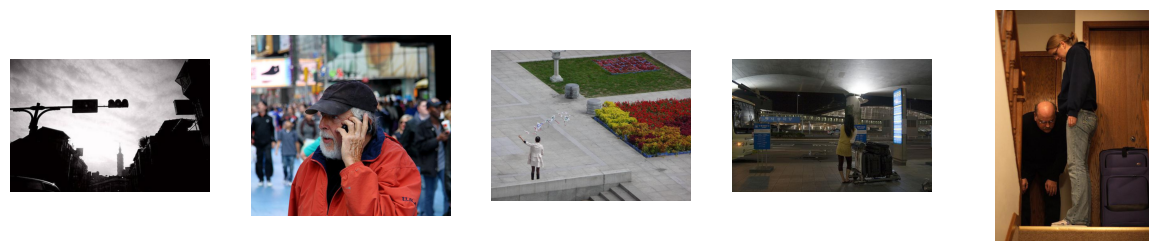

In [12]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# --- Load images (same 500-image slice as v1) ---
images_path = Path("../data/coco128/images/train2017")
image_files = list(images_path.glob("*.jpg"))
print(f"Found {len(image_files)} images")

# --- Embed the 500-image subset ---
image_embeddings = {}
for path in image_files[:500]:
    image_embeddings[str(path)] = embed_image(Image.open(path).convert("RGB"))
print(f"Embedded {len(image_embeddings)} images")

# --- Run a text query through your Section 6 function ---
query_vec = embed_text("people walking")
top5 = run_whole_image_baseline(query_vec, image_embeddings, top_k=5)

# --- Display the top-5 images ---
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, path in zip(axes, top5):
    ax.imshow(Image.open(path))
    ax.axis("off")
plt.show()

Detected 4 region(s)


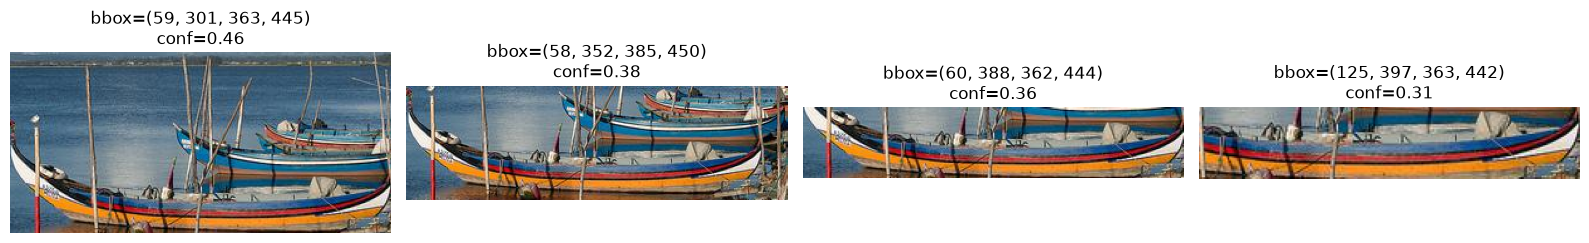

In [13]:
sample_path = image_files[1]
regions = extract_regions(sample_path)
print(f"Detected {len(regions)} region(s)")

fig, axes = plt.subplots(1, len(regions), figsize=(4 * len(regions), 4))
if len(regions) == 1:
    axes = [axes]  # so the loop below works even with just 1 region

for ax, (crop, bbox, conf) in zip(axes, regions):
    ax.imshow(crop)
    ax.set_title(f"bbox={bbox}\nconf={conf:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [14]:
object_counts = {}

for path in image_files:
    regions = extract_regions(str(path))
    object_counts[str(path)] = len(regions)

# sort images by object count
sorted_by_count = sorted(object_counts.items(), key=lambda x: x[1])

print("Simple candidates (fewest objects):")
for path, count in sorted_by_count[:20]:
    print(f"  {count} objects — {path}")

print("\nCluttered candidates (most objects):")
for path, count in sorted_by_count[-20:]:
    print(f"  {count} objects — {path}")

Simple candidates (fewest objects):
  1 objects — ../data/coco128/images/train2017/000000000360.jpg
  1 objects — ../data/coco128/images/train2017/000000000589.jpg
  1 objects — ../data/coco128/images/train2017/000000000629.jpg
  1 objects — ../data/coco128/images/train2017/000000000575.jpg
  1 objects — ../data/coco128/images/train2017/000000000400.jpg
  1 objects — ../data/coco128/images/train2017/000000000472.jpg
  1 objects — ../data/coco128/images/train2017/000000000471.jpg
  1 objects — ../data/coco128/images/train2017/000000000514.jpg
  1 objects — ../data/coco128/images/train2017/000000000502.jpg
  1 objects — ../data/coco128/images/train2017/000000000073.jpg
  1 objects — ../data/coco128/images/train2017/000000000081.jpg
  1 objects — ../data/coco128/images/train2017/000000000508.jpg
  1 objects — ../data/coco128/images/train2017/000000000133.jpg
  1 objects — ../data/coco128/images/train2017/000000000250.jpg
  1 objects — ../data/coco128/images/train2017/000000000034.jpg
  1 

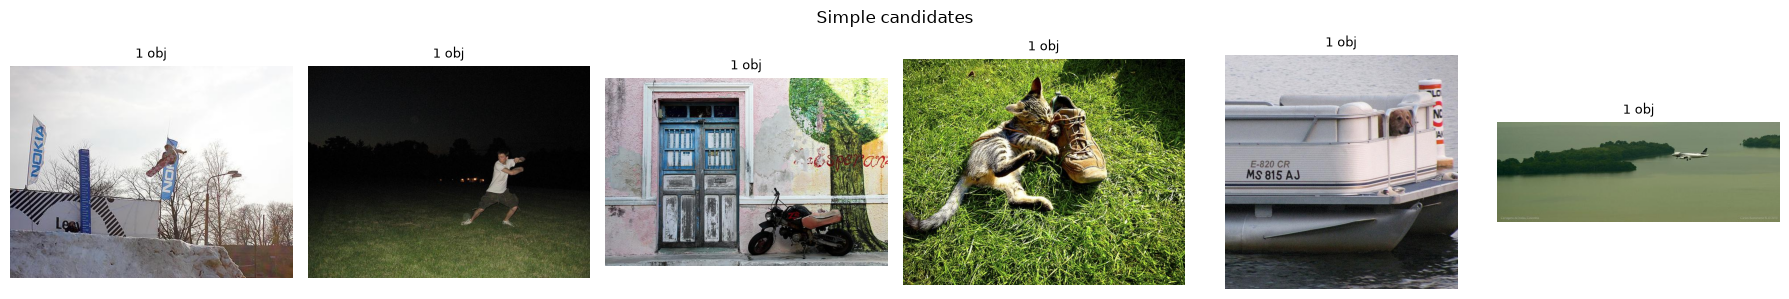

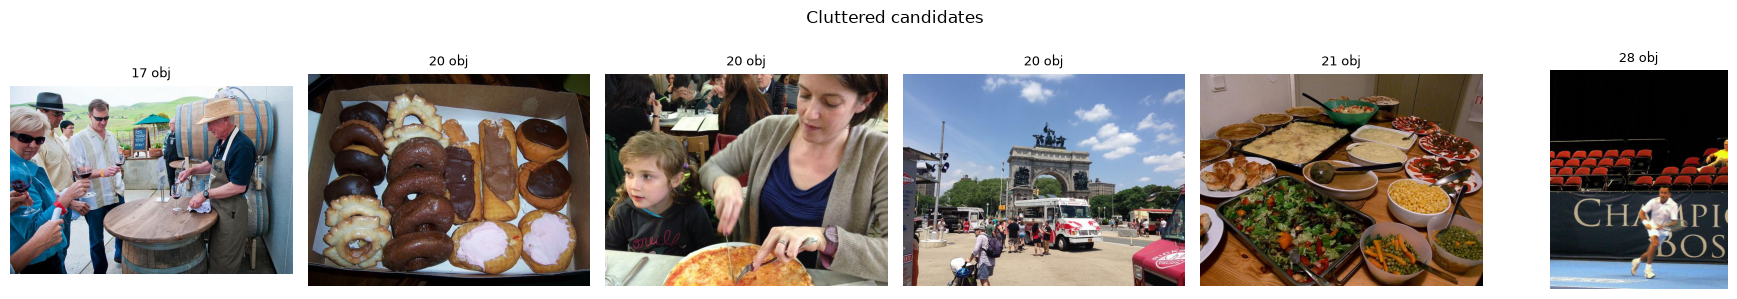

In [15]:
def show_images(paths, title):
    fig, axes = plt.subplots(1, len(paths), figsize=(3 * len(paths), 3))
    fig.suptitle(title)
    for ax, path in zip(axes, paths):
        ax.imshow(Image.open(path))
        ax.set_title(f"{object_counts[path]} obj", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

simple_paths = [p for p, c in sorted_by_count[:6]]
cluttered_paths = [p for p, c in sorted_by_count[-6:]]

show_images(simple_paths, "Simple candidates")
show_images(cluttered_paths, "Cluttered candidates")

## 8. Notes / next steps

- [ ] Curate `queries_simple.json` and `queries_cluttered.json` (see `dataset.md`)
- [ ] Implement the four `run_*` functions
- [ ] Cache embeddings to disk (mirror v1's `.pt` cache pattern) to avoid recomputation
- [ ] Run ablation, generate recall-per-round plots for both query sets
- [ ] Write up findings in `research_proposal.md` under a new "Results" section


In [16]:
final_simple = [p for p, c in sorted_by_count[:15]]
final_cluttered = [p for p, c in sorted_by_count[-15:]]

def build_skeleton(paths):
    return [
        {"query": "", "query_type": "text", "relevant_image_ids": [Path(p).name]}
        for p in paths
    ]

simple_skeleton = build_skeleton(final_simple)
cluttered_skeleton = build_skeleton(final_cluttered)

import json
Path("../data").mkdir(exist_ok=True)
with open("../data/queries_simple.json", "w") as f:
    json.dump(simple_skeleton, f, indent=2)
with open("../data/queries_cluttered.json", "w") as f:
    json.dump(cluttered_skeleton, f, indent=2)

print("Skeletons saved. Now fill in the empty \"query\" fields by hand.")

Skeletons saved. Now fill in the empty "query" fields by hand.


Embeddings ready.


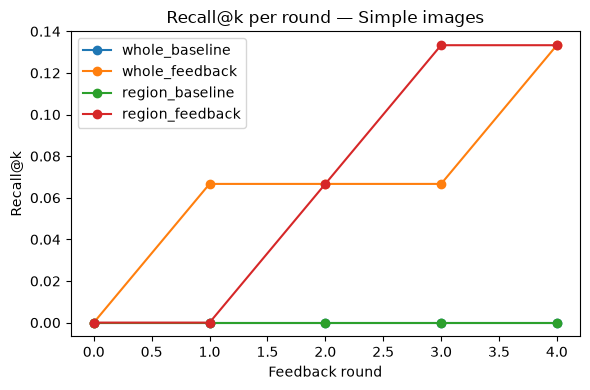

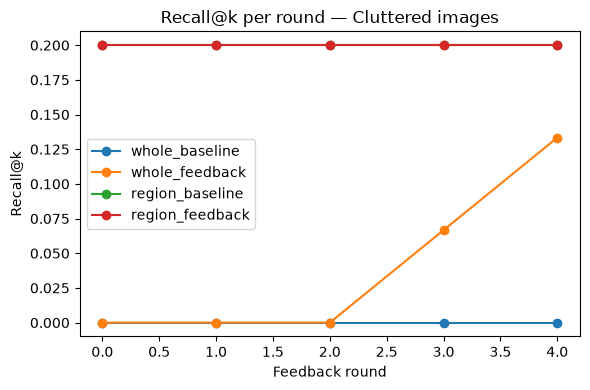

In [19]:
import json
from pathlib import Path

# --- Load labeled query sets ---
with open("../data/queries_simple.json") as f:
    queries_simple = json.load(f)
with open("../data/queries_cluttered.json") as f:
    queries_cluttered = json.load(f)

# --- Real relevance function (uses your labels, not a placeholder) ---
def make_relevance_fn(relevant_ids):
    relevant_names = set(relevant_ids)
    def relevance_fn(image_id):
        name = Path(image_id).name
        return True if name in relevant_names else False
    return relevance_fn

# --- Build embeddings dict for coco128 (whole-image) and region embeddings ---
image_embeddings = {str(p): embed_image(Image.open(p).convert("RGB")) for p in image_files}
region_embeddings = {str(p): embed_regions(str(p)) for p in image_files}
print("Embeddings ready.")

# --- Run all 4 conditions over a query set, return recall@k per round per condition ---
def evaluate_query_set(query_set, k=5, n_rounds=5):
    results = {
        "whole_baseline": [], "whole_feedback": [],
        "region_baseline": [], "region_feedback": [],
    }

    for entry in query_set:
        query_vec = embed_text(entry["query"])
        relevance_fn = make_relevance_fn(entry["relevant_image_ids"])
        relevant_ids = entry["relevant_image_ids"]

        # baseline conditions: single round, so we repeat the same recall value n_rounds times
        wb = run_whole_image_baseline(query_vec, image_embeddings, top_k=k)
        results["whole_baseline"].append([recall_at_k(wb, relevant_ids, k)] * n_rounds)

        rb = run_region_baseline(query_vec, region_embeddings, top_k=k)
        results["region_baseline"].append([recall_at_k(rb, relevant_ids, k)] * n_rounds)

        # feedback conditions: real per-round recall
        wf_rounds = run_whole_image_feedback(query_vec, image_embeddings, relevance_fn, n_rounds=n_rounds, top_k=k)
        results["whole_feedback"].append([recall_at_k(r, relevant_ids, k) for r in wf_rounds])

        rf_rounds = run_region_feedback(query_vec, region_embeddings, relevance_fn, n_rounds=n_rounds, top_k=k)
        results["region_feedback"].append([recall_at_k(r, relevant_ids, k) for r in rf_rounds])

    # average recall across all queries, per round, per condition
    averaged = {}
    for condition, all_query_rounds in results.items():
        n = len(all_query_rounds[0])
        averaged[condition] = [
            sum(q[i] for q in all_query_rounds) / len(all_query_rounds) for i in range(n)
        ]
    return averaged

simple_results = evaluate_query_set(queries_simple)
cluttered_results = evaluate_query_set(queries_cluttered)

plot_recall_per_round(simple_results, "Recall@k per round — Simple images")
plot_recall_per_round(cluttered_results, "Recall@k per round — Cluttered images")

In [20]:
test_query = embed_text(queries_cluttered[0]["query"])
test_relevant = queries_cluttered[0]["relevant_image_ids"]

baseline_result = run_region_baseline(test_query, region_embeddings, top_k=5)
feedback_result = run_region_feedback(test_query, region_embeddings, make_relevance_fn(test_relevant), n_rounds=5, top_k=5)

print("Baseline top-5:", [Path(p).name for p in baseline_result])
print("Feedback round 0:", [Path(p).name for p in feedback_result[0]])
print("Are they identical?", baseline_result == feedback_result[0])

Baseline top-5: ['000000000626.jpg', '000000000077.jpg', '000000000368.jpg', '000000000315.jpg', '000000000542.jpg']
Feedback round 0: ['000000000626.jpg', '000000000077.jpg', '000000000368.jpg', '000000000315.jpg', '000000000542.jpg']
Are they identical? True


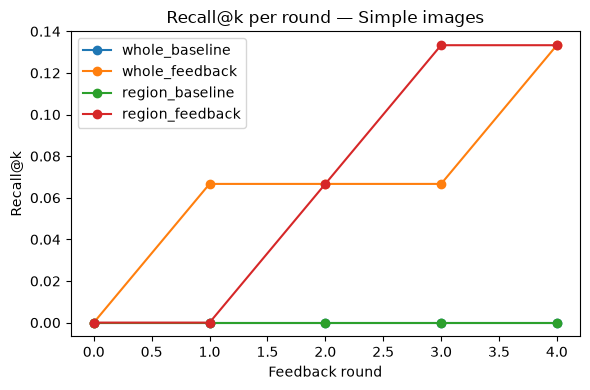

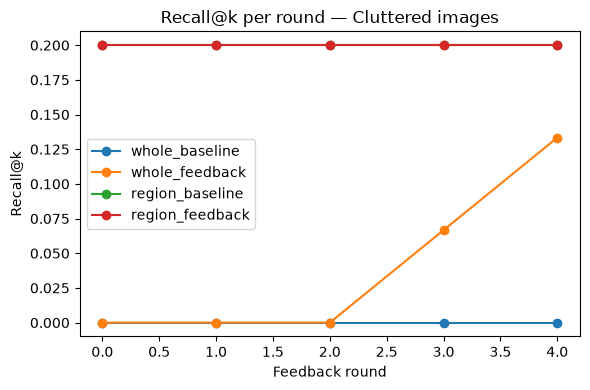

In [21]:
simple_results = evaluate_query_set(queries_simple)
cluttered_results = evaluate_query_set(queries_cluttered)

plot_recall_per_round(simple_results, "Recall@k per round — Simple images")
plot_recall_per_round(cluttered_results, "Recall@k per round — Cluttered images")